## Exploratory Data Analysis
### Income Targeting Project

This notebook explores the 1994–95 U.S. Census Bureau dataset used to build an income classification model for our retail client. The goal is to understand the data well enough to make principled decisions about preprocessing, feature engineering, and model design.

**Dataset:** 199,523 records × 42 columns (40 features + weight + label)  
**Target:** Binary income label — `<50K` vs `>50K`  
**Key challenge:** Strong class imbalance (~15:1 in sample), making accuracy a misleading metric.

In [67]:
import sys
sys.path.append('..')


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('Libraries loaded.')

Libraries loaded.


In [68]:
import os
os.chdir('/Users/madhuu/income-targeting-project')

from src.data.loader import load_config, load_raw_data
from src.data.cleaner import clean

config = load_config('config.yaml')
raw_df = load_raw_data(config)
X_clean, y, w = clean(raw_df, config)

df = X_clean.copy()
df['label']  = y.values
df['weight'] = w.values

print(f'Working directory: {os.getcwd()}')
print(f'Working dataframe shape: {df.shape}')

[loader] Stripped whitespace from 29 string columns
[loader] Loaded data: 199,523 rows x 42 columns
[loader] Missing values (NaN) per column:
hispanic origin                     874
state of previous residence         708
migration code-change in msa      99696
migration code-change in reg      99696
migration code-move within reg    99696
migration prev res in sunbelt     99696
country of birth father            6713
country of birth mother            6119
country of birth self              3393
[cleaner] Dropped 5 columns: ['year', 'detailed industry recode', 'detailed occupation recode', 'weight', 'label']
[cleaner] migration_data_absent: 99,696 rows flagged (50.0% of data)
[cleaner] Filled NaNs in 5 string columns with 'Unknown': ['hispanic origin', 'state of previous residence', 'country of birth father', 'country of birth mother', 'country of birth self']
[cleaner] No numeric NaNs found.

[cleaner] Label distribution:
          >50K (1): 12,382  (6.2%)
          <50K (0): 187,141

1. Dataset Overview

In [69]:
print('Shape:', df.shape)
print('\nColumn types:')
print(df.dtypes.value_counts())
print('\nFirst 3 rows (transposed):')
df.head(3).T

Shape: (199523, 40)

Column types:
object     28
int64      11
float64     1
Name: count, dtype: int64

First 3 rows (transposed):


,0,1,2
age,73,58,18
class of worker,Not in universe,Self-employed-not incorporated,Not in universe
education,High school graduate,Some college but no degree,10th grade
wage per hour,0,0,0
enroll in edu inst last wk,Not in universe,Not in universe,High school
marital stat,Widowed,Divorced,Never married
major industry code,Not in universe or children,Construction,Not in universe or children
major occupation code,Not in universe,Precision production craft & repair,Not in universe
race,White,White,Asian or Pacific Islander
hispanic origin,All other,All other,All other


In [70]:
missing = df.isnull().sum()
missing = missing[missing > 0]
if missing.empty:
    print('No missing values remain after cleaning.')
else:
    print('Remaining missing values:')
    print(missing)

No missing values remain after cleaning.


2. Class Imbalance

This is the most important structural feature of the dataset. At ~15:1, a naive classifier can achieve 93.8% accuracy by predicting everyone earns `<50K` — making accuracy a meaningless metric. We use weighted PR-AUC and F1 throughout.

Note: sample counts and population-weighted counts are reported separately. The weighted counts better reflect true population proportions given the stratified sampling design.

=== Sample Counts ===
  <50K (0): 187,141  (93.8%)
  >50K (1): 12,382  (6.2%)
  Sample ratio: 15.1:1

=== Population-Weighted Counts ===
  <50K: 325,004,647  (93.6%)
  >50K: 22,241,245  (6.4%)
  Weighted prevalence of >50K: 6.41%


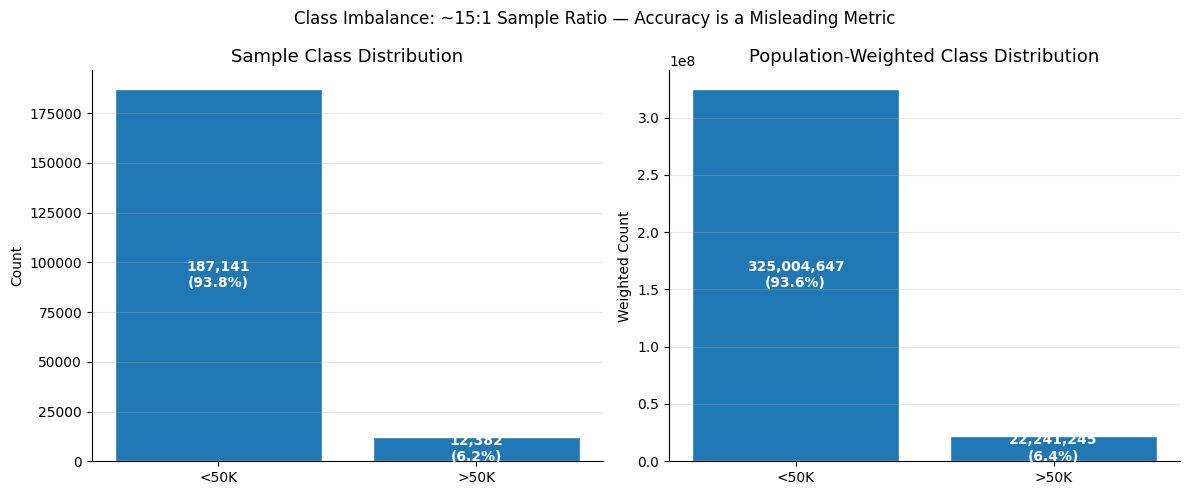

In [71]:
label_counts = y.value_counts().sort_index()
label_pct    = y.value_counts(normalize=True).sort_index() * 100

weighted_pos   = w[y == 1].sum()
weighted_neg   = w[y == 0].sum()
weighted_total = w.sum()
weighted_prev  = np.average(y, weights=w)  # population-representative prevalence

print('=== Sample Counts ===')
print(f'  <50K (0): {label_counts[0]:,}  ({label_pct[0]:.1f}%)')
print(f'  >50K (1): {label_counts[1]:,}  ({label_pct[1]:.1f}%)')
print(f'  Sample ratio: {label_counts[0]/label_counts[1]:.1f}:1')

print('\n=== Population-Weighted Counts ===')
print(f'  <50K: {weighted_neg:,.0f}  ({(1-weighted_prev)*100:.1f}%)')
print(f'  >50K: {weighted_pos:,.0f}  ({weighted_prev*100:.1f}%)')
print(f'  Weighted prevalence of >50K: {weighted_prev*100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['<50K', '>50K'], label_counts.values, edgecolor='white')
for i, (v, p) in enumerate(zip(label_counts.values, label_pct.values)):
    axes[0].text(i, v * 0.5, f'{v:,}\n({p:.1f}%)',
                 ha='center', va='center', fontsize=10, color='white', fontweight='bold')
axes[0].set_title('Sample Class Distribution', fontsize=13)
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(['<50K', '>50K'], [weighted_neg, weighted_pos], edgecolor='white')
for i, v in enumerate([weighted_neg, weighted_pos]):
    axes[1].text(i, v * 0.5, f'{v:,.0f}\n({v/weighted_total*100:.1f}%)',
                 ha='center', va='center', fontsize=10, color='white', fontweight='bold')
axes[1].set_title('Population-Weighted Class Distribution', fontsize=13)
axes[1].set_ylabel('Weighted Count')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Class Imbalance: ~15:1 Sample Ratio — Accuracy is a Misleading Metric',
             fontsize=12)
plt.subplots_adjust(top=0.88)             
plt.tight_layout()
plt.savefig('results/figures/class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

In [72]:
# One-hot encoding: converts categorical values into 0/1 indicator columns.

example_cols = ['tax filer stat', 'marital stat', 'major occupation code']
example_cols = [c for c in example_cols if c in df.columns]  # safe check

mini = df[example_cols].head(5).copy()
print("Before one-hot encoding (raw categories):")
display(mini)

# drop_first=False is used here so all categories are visible.
# In the actual training pipeline we use drop_first=True to avoid
# the dummy variable trap (perfect multicollinearity).
mini_ohe = pd.get_dummies(mini, columns=example_cols, drop_first=False)

print("\nAfter one-hot encoding (0/1 indicator columns):")
display(mini_ohe)

print(f"\nColumns before OHE : {len(example_cols)}")
print(f"Columns after OHE  : {len(mini_ohe.columns)}")
print(f"New columns created: {list(mini_ohe.columns)}")

Before one-hot encoding (raw categories):


,tax filer stat,marital stat,major occupation code
0,Nonfiler,Widowed,Not in universe
1,Head of household,Divorced,Precision production craft & repair
2,Nonfiler,Never married,Not in universe
3,Nonfiler,Never married,Not in universe
4,Nonfiler,Never married,Not in universe



After one-hot encoding (0/1 indicator columns):


,tax filer stat_Head of household,tax filer stat_Nonfiler,marital stat_Divorced,marital stat_Never married,marital stat_Widowed,major occupation code_Not in universe,major occupation code_Precision production craft & repair
0,False,True,False,False,True,True,False
1,True,False,True,False,False,False,True
2,False,True,False,True,False,True,False
3,False,True,False,True,False,True,False
4,False,True,False,True,False,True,False



Columns before OHE : 3
Columns after OHE  : 7
New columns created: ['tax filer stat_Head of household', 'tax filer stat_Nonfiler', 'marital stat_Divorced', 'marital stat_Never married', 'marital stat_Widowed', 'major occupation code_Not in universe', 'major occupation code_Precision production craft & repair']


This is the same encoding idea used in the training pipeline (engineer.py). For the full dataset, this expands categorical columns into many binary features that the model can learn from.

3.  Feature Engineering 

Standard preprocessing gets the data model-ready, but raw columns don't always capture the way income actually works in the real world. I created four additional features that reflect genuine economic patterns — peak earning years, investment behaviour, employment intensity, and retirement-age transitions.

Each feature below has a clear business rationale, and I validate it immediately by checking whether it actually 
separates income groups before deciding it's worth keeping.

In [73]:
df_fe = df.copy()

# Peak earning years (25–55)
# This is where wages are typically highest — past entry-level,
# before retirement transitions begin. Kept as a flag because the
# relationship with income isn't perfectly linear across all age ranges.
df_fe['prime_working_age'] = (
    (df_fe['age'] >= 25) & (df_fe['age'] <= 55)
).astype(int)

# Note: we're keeping the raw 'age' column in the model too.
# This flag is useful if the model needs a hard boundary signal,
# but since tree-based models can learn this boundary themselves,
# its marginal value is limited. We include it and let feature
# importance tell us whether it contributes.

# Retirement-age flag (62+)
# At 62, Social Security becomes accessible in the US — this often marks
# a shift from wages to fixed/investment income. Worth flagging separately
# because the income *type* changes even if the amount doesn't.
df_fe['is_retirement_age'] = (df_fe['age'] >= 62).astype(int)

# Capital activity flag
# Anyone reporting capital gains or stock dividends has investment income,
# which is strongly correlated with higher overall income. This collapses
# two sparse columns into one interpretable binary signal.
df_fe['capital_activity_flag'] = (
    (df_fe['capital gains'] > 0) |
    (df_fe['dividends from stocks'] > 0)
).astype(int)

# Work intensity buckets — for EDA interpretation only
# The raw 'weeks worked in year' column goes into the model as-is (numeric).
# This bucketing is just to make the validation table below readable.
df_fe['weeks_worked_bucket'] = pd.cut(
    df_fe['weeks worked in year'],
    bins=[-1, 26, 48, 52],
    labels=['Low (<= 26 wks)', 'Moderate (27–48 wks)', 'Full (49–52 wks)']
)

print("New features — first 5 rows:")
display(df_fe[['age', 'prime_working_age', 'is_retirement_age',
               'capital gains', 'dividends from stocks',
               'capital_activity_flag',
               'weeks worked in year', 'weeks_worked_bucket']].head())

New features — first 5 rows:


,age,prime_working_age,is_retirement_age,capital gains,dividends from stocks,capital_activity_flag,weeks worked in year,weeks_worked_bucket
0,73,0,1,0,0,0,0,Low (<= 26 wks)
1,58,0,0,0,0,0,52,Full (49–52 wks)
2,18,0,0,0,0,0,0,Low (<= 26 wks)
3,9,0,0,0,0,0,0,Low (<= 26 wks)
4,10,0,0,0,0,0,0,Low (<= 26 wks)


In [74]:
# Using population-weighted means throughout, consistent with our earlier
# finding that sample proportions alone can be misleading given stratified sampling.

features_to_check = ['prime_working_age', 'is_retirement_age', 'capital_activity_flag']

print("Population-weighted >50K rate by engineered features\n")

for feat in features_to_check:
    print(f"\n{feat}:")
    for grp, gdf in df_fe.groupby(feat):
        rate = np.average(gdf['label'], weights=gdf['weight'])
        n = len(gdf)
        label = "yes" if grp == 1 else "no"
        print(f"  {label:>4}  →  {rate*100:.1f}%  (n={n:,})")

print(f"\nweeks_worked_bucket:")
for grp, gdf in df_fe.groupby('weeks_worked_bucket', observed=True):
    rate = np.average(gdf['label'], weights=gdf['weight'])
    n = len(gdf)
    print(f"  {str(grp):<22} →  {rate*100:.1f}%  (n={n:,})")

Population-weighted >50K rate by engineered features


prime_working_age:
    no  →  2.3%  (n=112,285)
   yes  →  11.5%  (n=87,238)

is_retirement_age:
    no  →  6.7%  (n=170,623)
   yes  →  4.8%  (n=28,900)

capital_activity_flag:
    no  →  3.5%  (n=173,096)
   yes  →  25.4%  (n=26,427)

weeks_worked_bucket:
  Low (<= 26 wks)        →  0.8%  (n=111,199)
  Moderate (27–48 wks)   →  5.0%  (n=14,378)
  Full (49–52 wks)       →  14.9%  (n=73,946)


### What the validation shows

- **prime_working_age**: People in the 25–55 range earn >50K at a noticeably higher 
  rate than those outside it — the flag has signal, though the raw `age` column 
  already carries most of this information. Tree-based models will likely learn this 
  boundary anyway, so we'll monitor its feature importance.

- **is_retirement_age**: The >50K rate drops at 62+, which makes sense — wage income 
  declines even if investment income partially replaces it. This flag helps the model 
  distinguish that transition from the general age effect.

- **capital_activity_flag**: This one shows the strongest separation. People with any 
  capital gains or dividend activity are far more likely to earn >50K. Two sparse 
  columns collapsed into one clean signal.

- **weeks_worked_bucket**: Clear monotonic pattern — more weeks worked, higher income 
  rate. The raw numeric column captures this already, but the table confirms it's a 
  meaningful variable worth keeping.

**Decision:** `prime_working_age`, `is_retirement_age`, and `capital_activity_flag` 
are carried into the training pipeline. `weeks_worked_bucket` is EDA-only — the raw 
numeric goes into the model.

4. Fairness: Race and Sex


Before deciding how to handle these variables, I first want to understand  whether they actually carry income signal in this dataset. If they do, that itself is the problem, it means the raw data reflects historical structural inequality, and a model trained on it would learn to discriminate rather than predict genuine earning capacity.

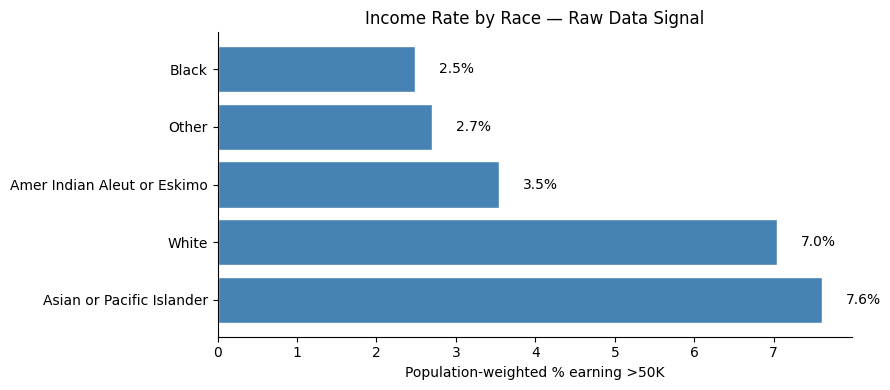


Full summary table:


,race,weighted_pct_over50k,sample_count
0,Asian or Pacific Islander,7.603422,5835.0
1,White,7.044240,167365.0
2,Amer Indian Aleut or Eskimo,3.546104,2251.0
3,Other,2.695873,3657.0
4,Black,2.489261,20415.0


In [85]:
# Population-weighted >50K rate by race (Using weighted means)

race_summary = (
    df.groupby('race')
    .apply(lambda g: pd.Series({
        'weighted_pct_over50k': np.average(g['label'], weights=g['weight']) * 100,
        'sample_count': len(g)
    }))
    .sort_values('weighted_pct_over50k', ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(race_summary['race'], race_summary['weighted_pct_over50k'],
               color='steelblue', edgecolor='white')

# Annotate each bar with the percentage
for bar, val in zip(bars, race_summary['weighted_pct_over50k']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=10)

ax.set_xlabel('Population-weighted % earning >50K')
ax.set_title('Income Rate by Race — Raw Data Signal', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../results/figures/income_by_race.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFull summary table:")
display(race_summary)

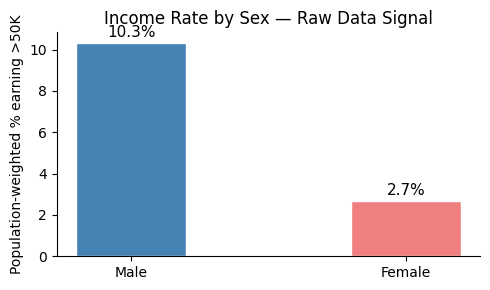


Full summary table:


,sex,weighted_pct_over50k,sample_count
0,Male,10.322152,95539.0
1,Female,2.672120,103984.0


In [86]:
# Population-weighted >50K rate by sex

sex_summary = (
    df.groupby('sex')
    .apply(lambda g: pd.Series({
        'weighted_pct_over50k': np.average(g['label'], weights=g['weight']) * 100,
        'sample_count': len(g)
    }))
    .sort_values('weighted_pct_over50k', ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.bar(sex_summary['sex'], sex_summary['weighted_pct_over50k'],
              color=['steelblue', 'lightcoral'], edgecolor='white', width=0.4)

for bar, val in zip(bars, sex_summary['weighted_pct_over50k']):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.3,
            f'{val:.1f}%', ha='center', fontsize=11)

ax.set_ylabel('Population-weighted % earning >50K')
ax.set_title('Income Rate by Sex — Raw Data Signal', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../results/figures/income_by_sex.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFull summary table:")
display(sex_summary)

**What this tells us**

Race and sex both show clear differences in income in this dataset, which is expected given that the data comes from 1994–95. These gaps reflect historical labor market conditions, not individual earning potential.

Including these variables in the model would cause it to learn and reproduce these past inequalities. In a real application, this could lead to systematically under-targeting women and people of color in a >50K income campaign.

Decision: We drop `race`, `sex`, and `hispanic origin` from the feature set using `drop_columns` in `config.yaml`, so the model never sees them. Instead, the model relies on factors like education, employment history, capital activity, and work intensity—variables that reflect individual circumstances rather than identity.

5. Census Weight Distribution

Each record carries a weight representing how many people in the actual U.S. population that record represents. This is a stratified sample — weights range from 38 to 18,656. We use these as `sample_weight` during model training and in all evaluation metrics to reflect true population proportions.

Weight column statistics:
count    199523.00
mean       1740.38
std         993.77
min          37.87
25%        1061.62
50%        1618.31
75%        2188.61
max       18656.30
Name: weight, dtype: float64


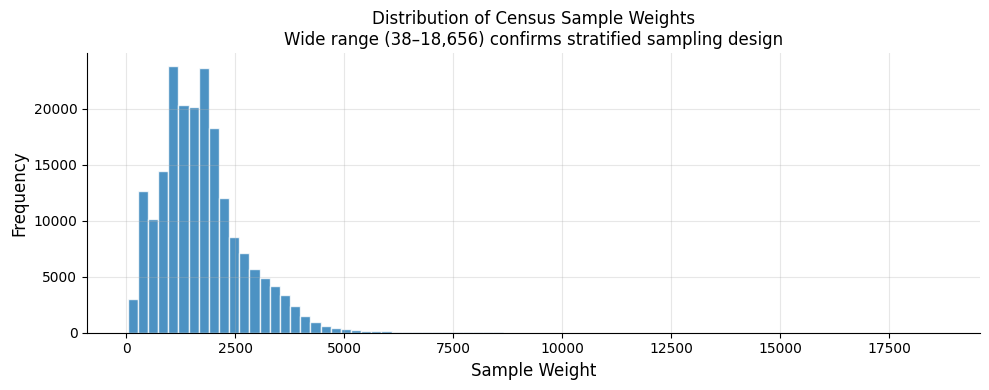

In [75]:
print('Weight column statistics:')
print(w.describe().round(2))

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(w, bins=80, edgecolor='white', alpha=0.8)
ax.set_xlabel('Sample Weight', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Census Sample Weights\n'
             'Wide range (38–18,656) confirms stratified sampling design', fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/weight_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

6. Numeric Feature Distributions

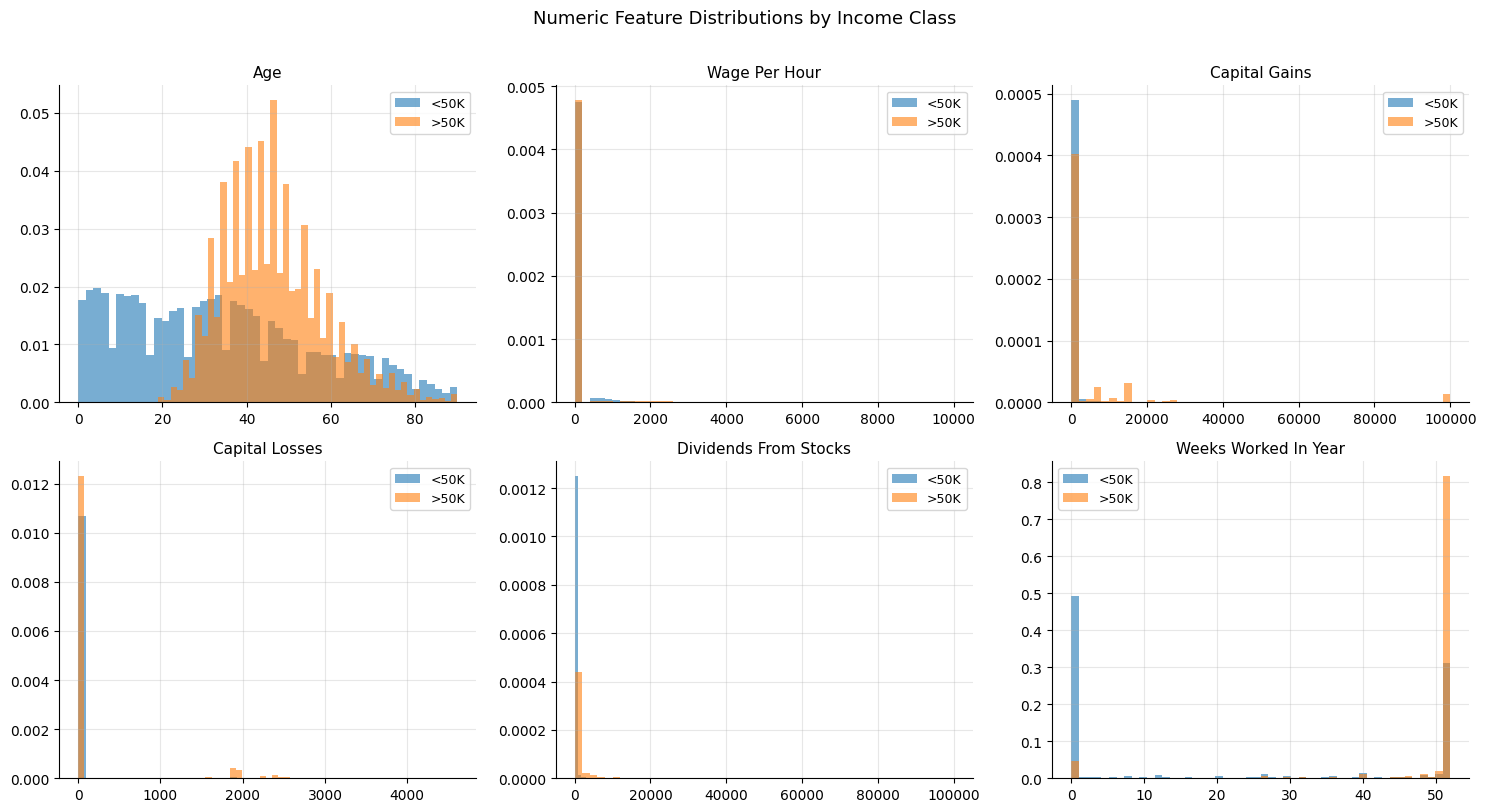

In [76]:
num_cols = ['age', 'wage per hour', 'capital gains',
            'capital losses', 'dividends from stocks', 'weeks worked in year']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    low  = df[df['label'] == 0][col]
    high = df[df['label'] == 1][col]
    axes[i].hist(low,  bins=50, alpha=0.6, label='<50K', density=True)
    axes[i].hist(high, bins=50, alpha=0.6, label='>50K', density=True)
    axes[i].set_title(col.title(), fontsize=11)
    axes[i].legend(fontsize=9)
    axes[i].grid(alpha=0.3)

plt.suptitle('Numeric Feature Distributions by Income Class', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../results/figures/numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

Key observation: wage, capital gains, capital losses, dividends are heavily right-skewed with median=0. Log1p transform applied in preprocessing.

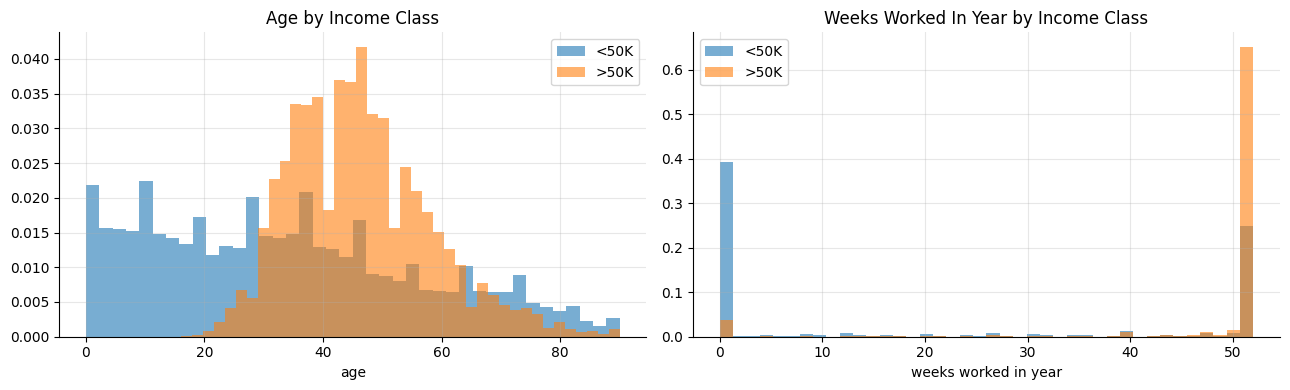

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col in zip(axes, ['age', 'weeks worked in year']):
    df[df['label']==0][col].hist(bins=40, ax=ax, alpha=0.6, label='<50K', density=True)
    df[df['label']==1][col].hist(bins=40, ax=ax, alpha=0.6, label='>50K', density=True)
    ax.set_title(f'{col.title()} by Income Class', fontsize=12)
    ax.set_xlabel(col)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/age_weeks_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

7. Categorical Feature Analysis

All income rates below are **population-weighted** using census sample weights — consistent with the rest of the project narrative. Unweighted rates would misrepresent the true population proportions given the stratified sampling design.

In [78]:
# Reusable weighted rate helper
def weighted_rate(group):
    return np.average(group['label'], weights=group['weight'])

print('Weighted rate helper defined.')

Weighted rate helper defined.


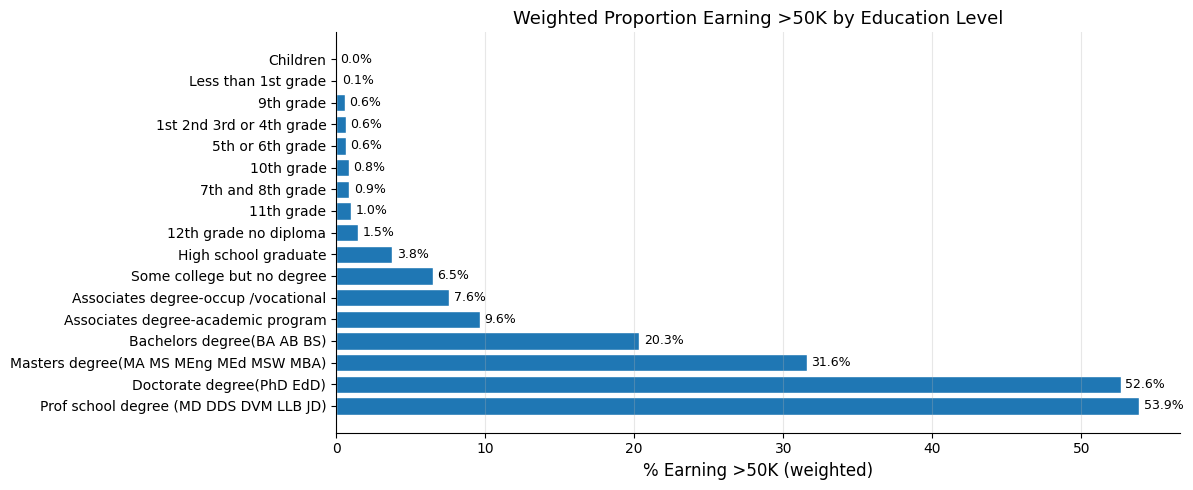

In [79]:
# Weighted >50K rate by education
edu_income = (
    df.groupby('education')
      .apply(weighted_rate)
      .sort_values(ascending=False)
      .reset_index(name='high_income_rate')
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(edu_income['education'], edu_income['high_income_rate'] * 100, edgecolor='white')
ax.set_xlabel('% Earning >50K (weighted)', fontsize=12)
ax.set_title('Weighted Proportion Earning >50K by Education Level', fontsize=13)
ax.grid(axis='x', alpha=0.3)
for i, row in edu_income.iterrows():
    ax.text(row['high_income_rate'] * 100 + 0.3,
            i, f"{row['high_income_rate']*100:.1f}%",
            va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../results/figures/education_income.png', dpi=150, bbox_inches='tight')
plt.show()

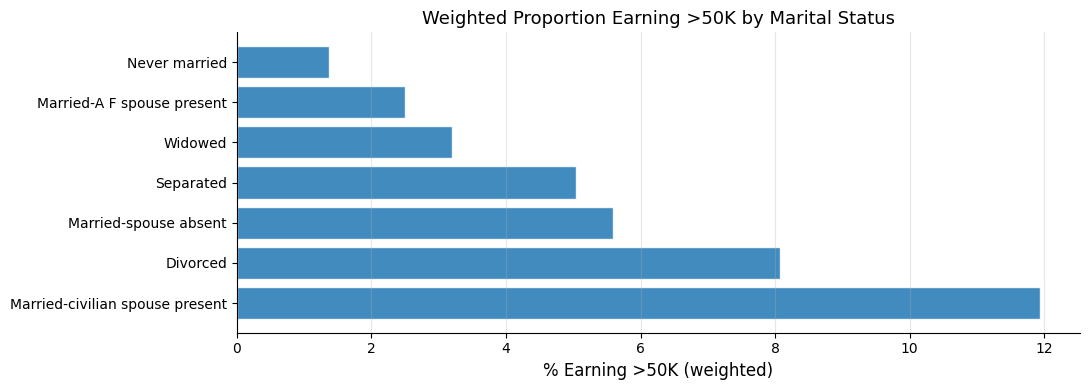

In [80]:
# Weighted >50K rate by marital status
marital_income = (
    df.groupby('marital stat')
      .apply(weighted_rate)
      .sort_values(ascending=False)
      .reset_index(name='high_income_rate')
)

fig, ax = plt.subplots(figsize=(11, 4))
ax.barh(marital_income['marital stat'], marital_income['high_income_rate'] * 100,
        edgecolor='white', alpha=0.85)
ax.set_xlabel('% Earning >50K (weighted)', fontsize=12)
ax.set_title('Weighted Proportion Earning >50K by Marital Status', fontsize=13)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/marital_income.png', dpi=150, bbox_inches='tight')
plt.show()

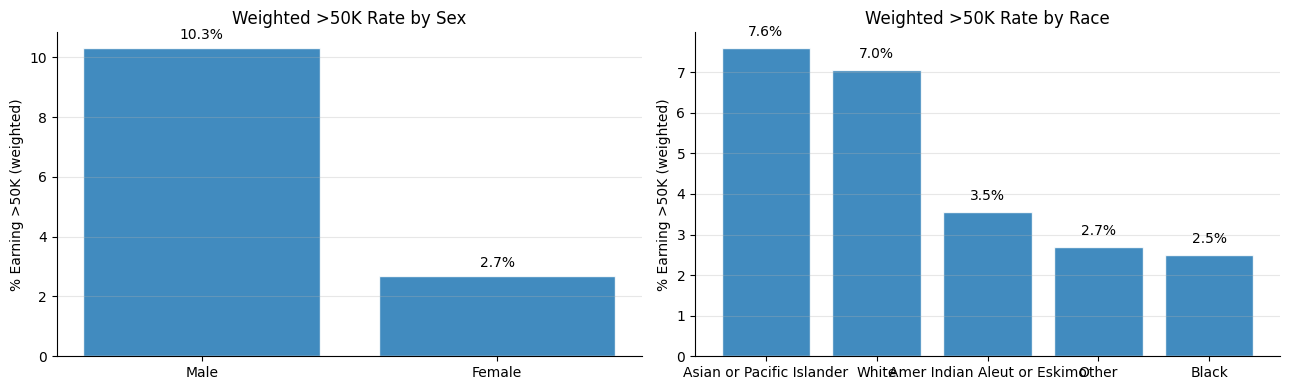

In [81]:
# Weighted >50K rate by sex and race
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col in zip(axes, ['sex', 'race']):
    rates = (
        df.groupby(col)
          .apply(weighted_rate)
          .sort_values(ascending=False) * 100
    )
    ax.bar(rates.index, rates.values, edgecolor='white', alpha=0.85)
    ax.set_ylabel('% Earning >50K (weighted)')
    ax.set_title(f'Weighted >50K Rate by {col.title()}', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    for i, v in enumerate(rates.values):
        ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../results/figures/demographic_income_rates.png', dpi=150, bbox_inches='tight')
plt.show()

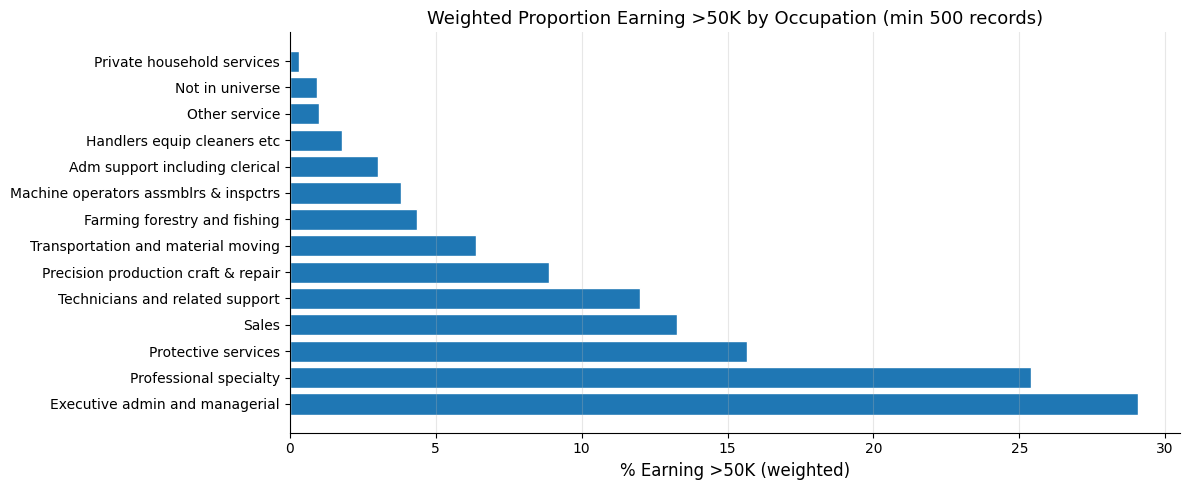

In [82]:
# Weighted >50K rate by occupation (min 500 records)
occ_counts = df.groupby('major occupation code')['label'].count()
valid_occs  = occ_counts[occ_counts > 500].index

occ_income = (
    df[df['major occupation code'].isin(valid_occs)]
      .groupby('major occupation code')
      .apply(weighted_rate)
      .sort_values(ascending=False)
      .reset_index(name='high_income_rate')
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(occ_income['major occupation code'],
        occ_income['high_income_rate'] * 100, edgecolor='white')
ax.set_xlabel('% Earning >50K (weighted)', fontsize=12)
ax.set_title('Weighted Proportion Earning >50K by Occupation (min 500 records)', fontsize=13)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/occupation_income.png', dpi=150, bbox_inches='tight')
plt.show()

8. Migration Column Missingness

Four migration columns have ~50% missing values. Rather than dropping them or the rows, we created a `migration_data_absent` binary flag (1 = all four migration columns were missing). This preserves the signal that "did not move" may carry for income prediction.

In [83]:
if 'migration_data_absent' in df.columns:
    mig_rate = (
        df.groupby('migration_data_absent')
          .apply(weighted_rate) * 100
    )
    mig_counts = df.groupby('migration_data_absent')['label'].count()

    print('Weighted >50K rate by migration_data_absent flag:')
    for flag in [0, 1]:
        label_str = 'Has migration data (absent=0)' if flag == 0 else 'Did not move (absent=1)'
        print(f'  {label_str}: {mig_rate[flag]:.2f}% earn >50K  '
              f'(n={mig_counts[flag]:,})')

    print('\nConclusion: missingness is informative — '
          'non-movers have a different income profile.')
else:
    print('migration_data_absent column not found.')

Weighted >50K rate by migration_data_absent flag:
  Has migration data (absent=0): 6.06% earn >50K  (n=99,827)
  Did not move (absent=1): 6.74% earn >50K  (n=99,696)

Conclusion: missingness is informative — non-movers have a different income profile.


8. Correlation Among Numeric Features

Note: correlation computed without sample weights (unweighted) — shown here for intuition only. All modelling and evaluation decisions use weighted metrics.

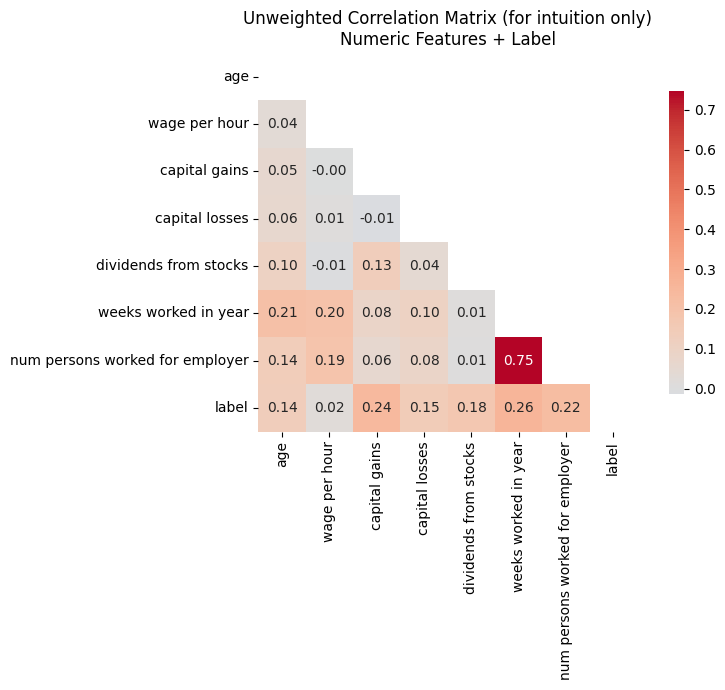

Top correlations with label (income) — unweighted:
weeks worked in year               0.262316
capital gains                      0.240725
num persons worked for employer    0.222684
dividends from stocks              0.175779
capital losses                     0.147417
age                                0.135720
wage per hour                      0.024528
Name: label, dtype: float64


In [84]:
num_feature_cols = ['age', 'wage per hour', 'capital gains', 'capital losses',
                    'dividends from stocks', 'weeks worked in year',
                    'num persons worked for employer', 'label']

corr = df[num_feature_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Unweighted Correlation Matrix (for intuition only)\n'
             'Numeric Features + Label', fontsize=12)
plt.tight_layout()
plt.savefig('../results/figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top correlations with label (income) — unweighted:')
print(corr['label'].drop('label').abs().sort_values(ascending=False))

**Key EDA Findings and Implications**

1. Strong class imbalance (~15:1 in sample)
A naive classifier can achieve high accuracy by predicting everyone earns <50K. Accuracy is therefore misleading. We use census sample weights during training and evaluate models using weighted PR-AUC and F1 instead of accuracy.

2. Wide census weight range (38–18,656)
The dataset is a stratified sample. Each record represents a different number of real individuals in the U.S. population. All model training and evaluation metrics use sample weights to reflect true population impact.

3. Wage, capital gains, and dividends are heavily right-skewed (median = 0)
These features contain extreme outliers and long right tails. A log1p transformation is applied before modeling to stabilise variance and reduce leverage of extreme values.

4. ~50% missing values in four migration columns
Missingness is not random. It likely indicates individuals who did not move. Instead of dropping these columns, we created a migration_data_absent flag to preserve this potentially informative signal.

5. Education is strongly predictive of income
Higher education levels correspond to dramatically higher weighted >50K rates. This suggests strong socioeconomic stratification and reinforces the importance of education-related features in modeling.

6. Marital status is strongly predictive
“Married-civ-spouse” has the highest weighted >50K rate by a wide margin, indicating strong demographic signal relevant for marketing segmentation.

7. Income >50K peaks around ages 40–55
This aligns with peak career years. From a business perspective, this represents a prime marketing window for high-value targeting.

8. Children (age <15) are included in the dataset
Individuals under 15 cannot realistically earn >50K. The model captures this automatically through the age feature without requiring manual filtering.